
# Arabic Hate Speech Detection using AraBERT v2
## MSBDA 882 - Advanced Machine Learning Course Project

This notebook is prepared for the Arabic Hate Speech Detection project.

### Main Goals
- Load the required dataset from Hugging Face.
- Explore and clean Arabic text data.
- Train a baseline model using TF-IDF + Logistic Regression.
- Fine-tune AraBERT v2 for Arabic hate speech classification.
- Evaluate models using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Dataset:
`manueltonneau/arabic-hate-speech-superset`


## 1. Install Required Libraries

In [2]:

!pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib

import torch


print(f"PyTorch Version: {torch.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch Version: 2.5.1+cu121
Using device: cuda


## 2. Import Libraries

In [5]:
import pandas as pd
import numpy as np
import torch

from transformers import AutoTokenizer


In [ ]:

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)



## 3. Reproducibility Settings

In [5]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [ ]:
from huggingface_hub import login

login("Your Token")

## 4. Load the Required Dataset

In [7]:
dataset = load_dataset("manueltonneau/arabic-hate-speech-superset")
dataset


C:\Users\dhoms\anaconda3\envs\pytorch_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dhoms\.cache\huggingface\hub\datasets--manueltonneau--arabic-hate-speech-superset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating train split: 100%|██████████| 449078/449078 [00:01<00:00, 251378.01 exam

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'post_author_country_location'],
        num_rows: 449078
    })
})

## 5. Convert Dataset to Pandas DataFrame

In [10]:
if "train" in dataset:
    df = pd.DataFrame(dataset["train"])
else:
    first_split = list(dataset.keys())[0]
    df = pd.DataFrame(dataset[first_split])

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Dataset shape: (449078, 6)
Columns: ['text', 'labels', 'source', 'dataset', 'nb_annotators', 'post_author_country_location']


,text,labels,source,dataset,nb_annotators,post_author_country_location
0,الوزير جبران باسيل تاج راسك يا جربان ممنوع بعد...,0.0,Twitter,L-HSAB,3,unknown
1,صديقي انت ابن جامعه اللعبه اكبر من داعش اللعبه...,0.0,Twitter,L-HSAB,3,unknown
2,و مصلحة لبنان تبدأ باستخراج النفط و الغاز لوقف...,0.0,Twitter,L-HSAB,3,unknown
3,وليد جنبلاط كاتب الحكمة يا قذر,0.0,Twitter,L-HSAB,3,unknown
4,شو بتلبقلك كلمة خنزير بتجي مفصله على قياسك وشك...,0.0,Twitter,L-HSAB,3,unknown


## 6. Detect Text and Label Columns

In [11]:


possible_text_columns = ["text", "tweet", "content", "sentence", "comment"]
possible_label_columns = ["label", "labels", "class", "target"]

text_col = None
label_col = None

for col in possible_text_columns:
    if col in df.columns:
        text_col = col
        break

for col in possible_label_columns:
    if col in df.columns:
        label_col = col
        break

if text_col is None:
    raise ValueError(f"Text column not found. Available columns: {df.columns.tolist()}")

if label_col is None:
    raise ValueError(f"Label column not found. Available columns: {df.columns.tolist()}")

print("Text column:", text_col)
print("Label column:", label_col)

df[[text_col, label_col]].head()


Text column: text
Label column: labels


,text,labels
0,الوزير جبران باسيل تاج راسك يا جربان ممنوع بعد...,0.0
1,صديقي انت ابن جامعه اللعبه اكبر من داعش اللعبه...,0.0
2,و مصلحة لبنان تبدأ باستخراج النفط و الغاز لوقف...,0.0
3,وليد جنبلاط كاتب الحكمة يا قذر,0.0
4,شو بتلبقلك كلمة خنزير بتجي مفصله على قياسك وشك...,0.0


## 7. Basic Dataset Exploration

Number of samples: 449078

Missing values:
text      0
labels    0
dtype: int64

Label distribution:
labels
0.0    432532
1.0     16546
Name: count, dtype: int64


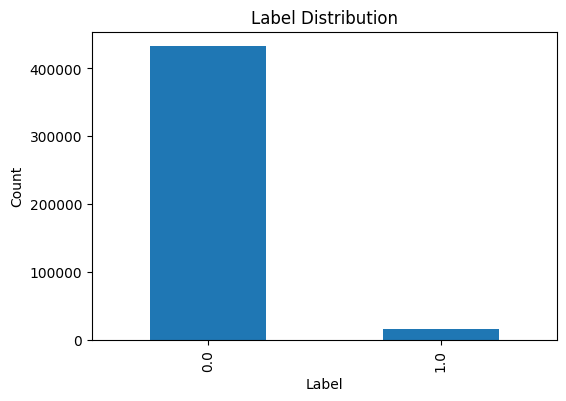

In [12]:

print("Number of samples:", len(df))
print("\nMissing values:")
print(df[[text_col, label_col]].isnull().sum())

print("\nLabel distribution:")
print(df[label_col].value_counts())

plt.figure(figsize=(6, 4))
df[label_col].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()


## 8. Arabic Text Cleaning

In [13]:

def clean_arabic_text(text):
    text = str(text)

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"@\w+", " ", text)

    text = re.sub(r"#", " ", text)

    arabic_diacritics = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
    text = re.sub(arabic_diacritics, "", text)

    text = re.sub(r"[إأآٱ]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)

    text = re.sub(r"ـ", "", text)

    text = re.sub(r"[^\u0600-\u06FF\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text


In [14]:

df = df[[text_col, label_col]].dropna().copy()

df["clean_text"] = df[text_col].apply(clean_arabic_text)

df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

df[[text_col, "clean_text", label_col]].head()


,text,clean_text,labels
0,الوزير جبران باسيل تاج راسك يا جربان ممنوع بعد...,الوزير جبران باسيل تاج راسك يا جربان ممنوع بعد...,0.0
1,صديقي انت ابن جامعه اللعبه اكبر من داعش اللعبه...,صديقي انت ابن جامعه اللعبه اكبر من داعش اللعبه...,0.0
2,و مصلحة لبنان تبدأ باستخراج النفط و الغاز لوقف...,و مصلحة لبنان تبدا باستخراج النفط و الغاز لوقف...,0.0
3,وليد جنبلاط كاتب الحكمة يا قذر,وليد جنبلاط كاتب الحكمة يا قذر,0.0
4,شو بتلبقلك كلمة خنزير بتجي مفصله على قياسك وشك...,شو بتلبقلك كلمة خنزير بتجي مفصله علي قياسك وشكلك,0.0


## 9. Encode Labels

In [15]:


unique_labels = sorted(df[label_col].unique())

label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {idx: label for label, idx in label2id.items()}

df["label_id"] = df[label_col].map(label2id)

print("label2id:", label2id)
print("id2label:", id2label)

df[["clean_text", label_col, "label_id"]].head()


label2id: {np.float64(0.0): 0, np.float64(1.0): 1}
id2label: {0: np.float64(0.0), 1: np.float64(1.0)}


,clean_text,labels,label_id
0,الوزير جبران باسيل تاج راسك يا جربان ممنوع بعد...,0.0,0
1,صديقي انت ابن جامعه اللعبه اكبر من داعش اللعبه...,0.0,0
2,و مصلحة لبنان تبدا باستخراج النفط و الغاز لوقف...,0.0,0
3,وليد جنبلاط كاتب الحكمة يا قذر,0.0,0
4,شو بتلبقلك كلمة خنزير بتجي مفصله علي قياسك وشكلك,0.0,0


## 10. Train, Validation, and Test Split

In [16]:

X = df["clean_text"]
y = df["label_id"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 314335
Validation size: 67358
Test size: 67358


# Part A: Baseline Model — TF-IDF + Logistic Regression

In [17]:

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)


In [18]:

print("Baseline Model Classification Report:")
print(classification_report(
    y_test,
    baseline_predictions,
    target_names=[str(id2label[i]) for i in sorted(id2label.keys())],
    zero_division=0
))


Baseline Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     64876
         1.0       0.16      0.70      0.26      2482

    accuracy                           0.85     67358
   macro avg       0.57      0.78      0.59     67358
weighted avg       0.96      0.85      0.89     67358



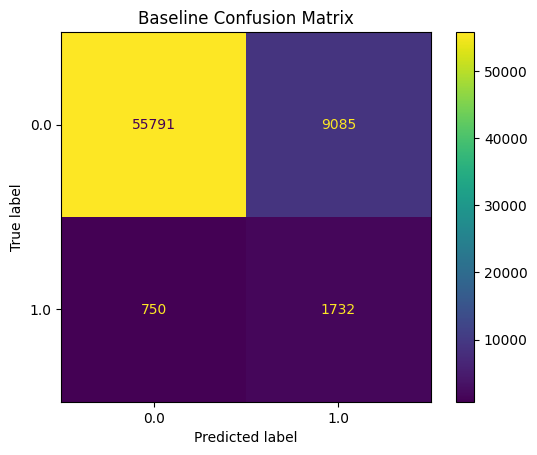

In [19]:

baseline_cm = confusion_matrix(y_test, baseline_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=[str(id2label[i]) for i in sorted(id2label.keys())]
)

disp.plot(values_format="d")
plt.title("Baseline Confusion Matrix")
plt.show()


# Part B: Deep Learning Model — AraBERT v2

In [20]:

model_name = "aubmindlab/bert-base-arabertv2"

tokenizer = AutoTokenizer.from_pretrained(model_name)


C:\Users\dhoms\anaconda3\envs\pytorch_env\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dhoms\.cache\huggingface\hub\models--aubmindlab--bert-base-arabertv2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## 11. Tokenization

In [21]:

train_texts = X_train.tolist()
val_texts = X_val.tolist()
test_texts = X_test.tolist()

train_labels = y_train.tolist()
val_labels = y_val.tolist()
test_labels = y_test.tolist()

train_encodings = tokenizer(train_texts, truncation=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, max_length=128)


## 12. Create PyTorch Dataset Class

In [22]:

class ArabicHateSpeechDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = ArabicHateSpeechDataset(train_encodings, train_labels)
val_dataset = ArabicHateSpeechDataset(val_encodings, val_labels)
test_dataset = ArabicHateSpeechDataset(test_encodings, test_labels)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


## 13. Load AraBERT Model

In [23]:

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label2id),
    id2label={str(k): str(v) for k, v in id2label.items()},
    label2id={str(k): int(v) for k, v in label2id.items()}
)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8930.16it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from

## 14. Define Evaluation Metrics

In [24]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


## 15. Training Arguments

In [25]:

training_args = TrainingArguments(
    output_dir="./arabert_hate_speech_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none"
)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## 16. Create Trainer

In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

## 17. Train AraBERT

In [27]:

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.130522,0.145282,0.966047,0.958102,0.966047,0.959553
2,0.081582,0.150225,0.967858,0.960922,0.967858,0.960985


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.03it/s]


TrainOutput(global_step=78584, training_loss=0.13786162917038508, metrics={'train_runtime': 11947.6239, 'train_samples_per_second': 52.619, 'train_steps_per_second': 6.577, 'total_flos': 1.70237297955867e+16, 'train_loss': 0.13786162917038508, 'epoch': 2.0})

## 18. Evaluate AraBERT on Test Set

In [28]:

test_results = trainer.evaluate(test_dataset)

print("AraBERT Test Results:")
print(test_results)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.081582,0.146334,2,0.968927,0.962848,0.968927,0.962089


AraBERT Test Results:
{'eval_loss': 0.14633429050445557, 'eval_accuracy': 0.9689272246800676, 'eval_precision': 0.962848040109314, 'eval_recall': 0.9689272246800676, 'eval_f1': 0.9620893605916411}


In [29]:

predictions_output = trainer.predict(test_dataset)

arabert_predictions = np.argmax(predictions_output.predictions, axis=-1)

print("AraBERT Classification Report:")
print(classification_report(
    test_labels,
    arabert_predictions,
    target_names=[str(id2label[i]) for i in sorted(id2label.keys())],
    zero_division=0
))


AraBERT Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     64876
         1.0       0.71      0.27      0.39      2482

    accuracy                           0.97     67358
   macro avg       0.84      0.63      0.69     67358
weighted avg       0.96      0.97      0.96     67358



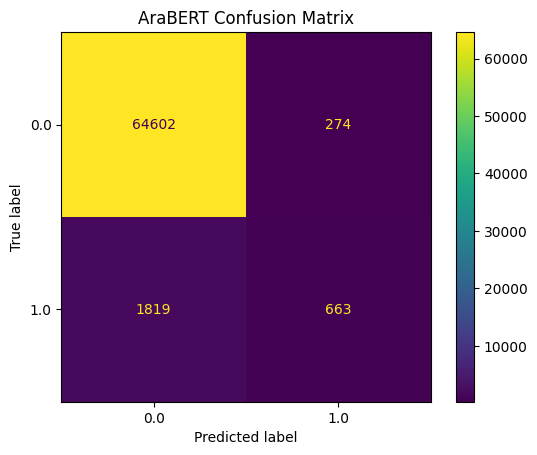

In [30]:

arabert_cm = confusion_matrix(test_labels, arabert_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=arabert_cm,
    display_labels=[str(id2label[i]) for i in sorted(id2label.keys())]
)

disp.plot(values_format="d")
plt.title("AraBERT Confusion Matrix")
plt.show()


## 19. Compare Baseline and AraBERT

In [31]:

baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(
    y_test,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)

arabert_precision, arabert_recall, arabert_f1, _ = precision_recall_fscore_support(
    test_labels,
    arabert_predictions,
    average="weighted",
    zero_division=0
)

arabert_accuracy = accuracy_score(test_labels, arabert_predictions)

comparison_df = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "AraBERT v2"],
    "Accuracy": [baseline_accuracy, arabert_accuracy],
    "Precision": [baseline_precision, arabert_precision],
    "Recall": [baseline_recall, arabert_recall],
    "F1-score": [baseline_f1, arabert_f1]
})

comparison_df


,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.853989,0.956276,0.853989,0.894733
1,AraBERT v2,0.968927,0.962848,0.968927,0.962089


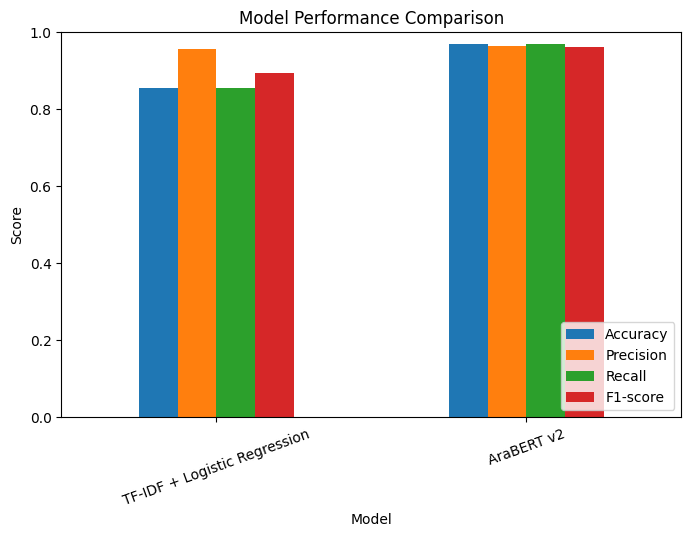

In [32]:

comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(8, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.show()


In [34]:
import os

save_directory = "./AraBERT_Saved_Model"
os.makedirs(save_directory, exist_ok=True)

trainer.save_model(save_directory)

tokenizer.save_pretrained(save_directory)



Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.35it/s]


('./AraBERT_Saved_Model\\tokenizer_config.json',
 './AraBERT_Saved_Model\\tokenizer.json')


## 20. Discussion

The baseline model uses TF-IDF features with Logistic Regression. This model is simple and useful as a comparison point.

AraBERT v2 is a transformer-based deep learning model designed for Arabic text. It can understand context better than traditional TF-IDF features, which makes it more suitable for Arabic hate speech detection.

For the final report, discuss:
- Dataset size and label distribution.
- Preprocessing steps.
- Baseline model results.
- AraBERT model results.
- Confusion matrix analysis.
- Common errors and possible reasons.
- Possible future improvements.
